# 🧬 Linear Regression — Diabetes Disease Progression
Self-contained regression workflow on the UCI Diabetes dataset.


Diabetes dataset shape: (442, 10)
R²                  : 0.4526
Mean squared error  : 2900.19
Mean absolute error : 42.79


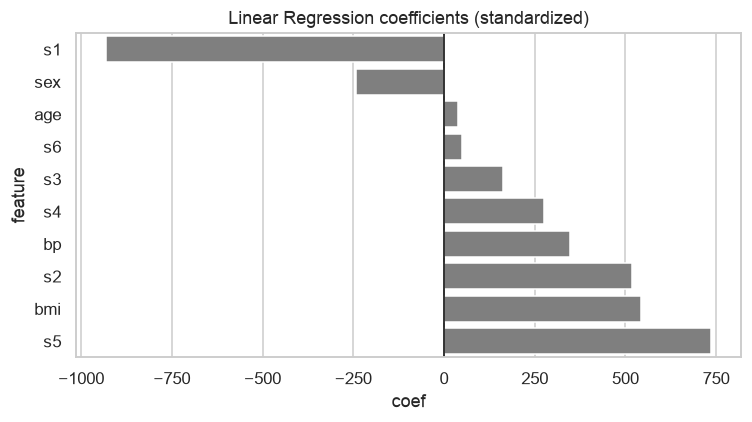

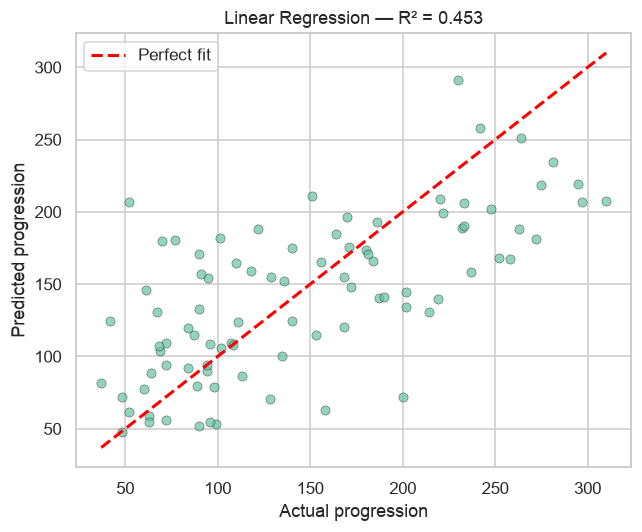

In [1]:
# ============================================================
# Setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

# ============================================================
# Load Diabetes dataset (UCI open database)
# 442 patients, 10 baseline variables -> disease progression
# ============================================================
diabetes = load_diabetes()
X_d, y_d = diabetes.data, diabetes.target
feat_d = diabetes.feature_names
print(f"Diabetes dataset shape: {X_d.shape}")

# ============================================================
# Train Linear Regression
# ============================================================
X_tr, X_te, y_tr, y_te = train_test_split(X_d, y_d, test_size=0.20,
                                          random_state=42)
linreg = LinearRegression()
linreg.fit(X_tr, y_tr)
y_pred = linreg.predict(X_te)

r2  = r2_score(y_te, y_pred)
mse = mean_squared_error(y_te, y_pred)
mae = mean_absolute_error(y_te, y_pred)
print(f"R²                  : {r2:.4f}")
print(f"Mean squared error  : {mse:.2f}")
print(f"Mean absolute error : {mae:.2f}")

# ============================================================
# Coefficients (standardized inputs -> standardized slopes)
# ============================================================
coef_d = pd.DataFrame({"feature": feat_d,
                       "coef": linreg.coef_}).sort_values("coef")
plt.figure(figsize=(7, 4))
sns.barplot(data=coef_d, x="coef", y="feature", color="#7f7f7f")
plt.axvline(0, color="k", lw=1)
plt.title("Linear Regression coefficients (standardized)")
plt.tight_layout(); plt.show()

# ============================================================
# Predicted vs actual
# ============================================================
plt.figure(figsize=(6, 5))
plt.scatter(y_te, y_pred, alpha=0.7, edgecolors="k", linewidths=0.3)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual progression"); plt.ylabel("Predicted progression")
plt.title(f"Linear Regression — R² = {r2:.3f}")
plt.legend(); plt.tight_layout(); plt.show()
